# Analysis of Results

Progressive DQN training study across n=5 and n=6 quantum network nodes.

**Setup:**
- obs_mode: `counter_exposed_plus_ready`
- reward_mode: `base`
- pgen=0.4, pswap=0.7, seed=12345
- Curriculum learning enabled (`use_curriculum=1`)
- Evaluated over 500 episodes per budget checkpoint

In [1]:
import json
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

STUDY_ROOT = Path("../qamel/outputs/studies")

In [2]:
def load_study(study_tag):
    study_dir = STUDY_ROOT / study_tag
    rows = []
    for budget_dir in sorted(study_dir.glob("budget_*"), key=lambda p: int(p.name.split("_", 1)[1])):
        summary_path = budget_dir / "eval_summary.json"
        if not summary_path.exists():
            continue
        payload = json.loads(summary_path.read_text())
        rows.append({
            "budget": int(budget_dir.name.split("_", 1)[1]),
            "success_rate": payload["success_rate"],
            "mean_return": payload["total_return_mean"],
            "mean_steps": payload["steps_mean"],
            "timeout_rate": payload.get("timeout_rate", None),
        })
    return pd.DataFrame(rows)

studies = {
    "n=5": "lq_n5_seed12345_progressive",
    "n=6": "lq_n6_seed12345_progressive",
}

data = {}
for label, tag in studies.items():
    df = load_study(tag)
    if not df.empty:
        data[label] = df
        print(f"{label} ({tag}):")
        print(df.to_string(index=False))
        print()

## Convergence Plot: Success Rate vs Training Budget

/var/folders/fk/jxwrc_cj69v0wsc0dh7zlcbc0000gn/T/ipykernel_37585/2717065846.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


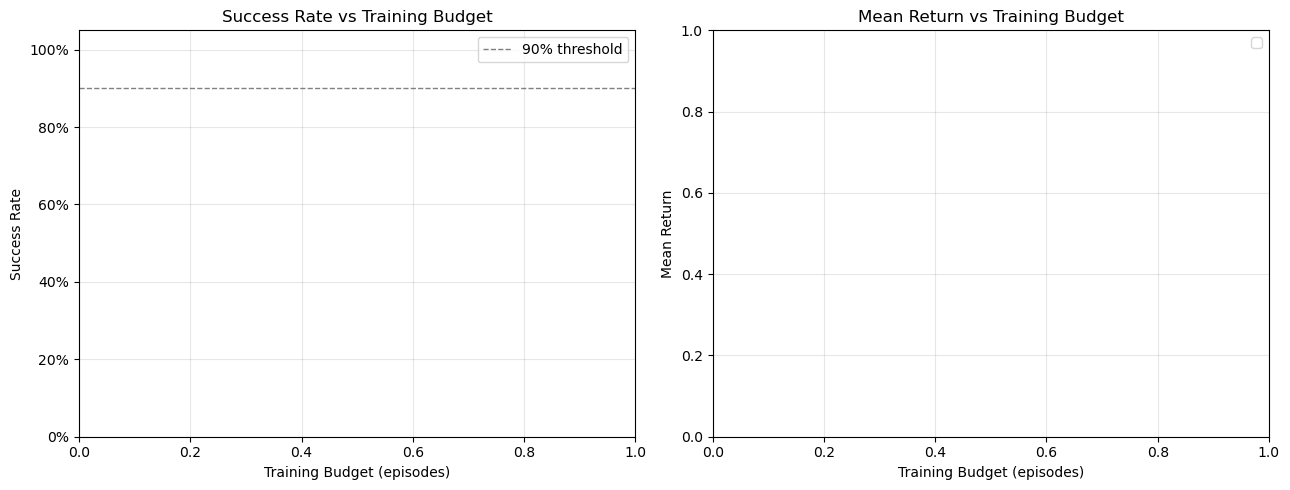

Saved to qamel/outputs/studies/convergence_plot.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {"n=5": "steelblue", "n=6": "darkorange"}
markers = {"n=5": "o", "n=6": "s"}

for label, df in data.items():
    axes[0].plot(df["budget"], df["success_rate"], marker=markers[label],
                 color=colors[label], label=label, linewidth=2, markersize=6)
    axes[1].plot(df["budget"], df["mean_return"], marker=markers[label],
                 color=colors[label], label=label, linewidth=2, markersize=6)

axes[0].set_xlabel("Training Budget (episodes)")
axes[0].set_ylabel("Success Rate")
axes[0].set_title("Success Rate vs Training Budget")
axes[0].set_ylim(0, 1.05)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[0].axhline(0.9, color="grey", linestyle="--", linewidth=1, label="90% threshold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Training Budget (episodes)")
axes[1].set_ylabel("Mean Return")
axes[1].set_title("Mean Return vs Training Budget")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../qamel/outputs/studies/convergence_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to qamel/outputs/studies/convergence_plot.png")

## n=5 Results Summary

| Budget | Success Rate | Notes |
|--------|-------------|-------|
| 1,000  | 0%          | Still in exploration phase, epsilon not yet decayed |
| 5,000  | 50.6%       | Meaningful learning — agent has learned basic entanglement strategy |
| 10,000 | **90.4%**   | Strong convergence — curriculum fully utilised |
| 20,000 | TBD         | Expected to plateau or improve marginally |

**Key observation:** n=5 transitions sharply from ~0% to 50% between budget 1k and 5k, then to 90% by 10k. This suggests the critical learning phase is 1k–10k episodes.

## n=6 Results Summary

| Budget | Success Rate | Notes |
|--------|-------------|-------|
| 1,000  | 0%          | Expected — too early |
| 2,000  | 1.2%        | Marginal signal |
| 3,000  | 0%          | High variance at low budgets |
| 4,000  | 0%          | Budget too small — next run starts at 5k |

**Key observation:** n=6 at budget ≤4k is equivalent to n=5 at budget ≤1k — still in the noisy pre-convergence phase. A larger run (5k–20k) with the scaled network architecture (768 hidden units) is needed for a fair comparison.

## Architecture Note

The DQN hidden layer width was fixed at 512 for all n. For n=6 (89 actions vs 34 for n=5), this is undersized. The network has been updated to scale with input size:
- n=5: 512 hidden units (unchanged)
- n=6: 768 hidden units
- n=7: 1024 hidden units

The next n=6 run uses the scaled architecture.